In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
import CNN_scratch
import cv2
from CNN_scratch import GradCam
%matplotlib inline

In [2]:
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(),])

dataset = datasets.ImageFolder(root="C://Users//USER//Downloads//archive (2)//256_ObjectCategories", transform=transform)

remove_class_name = '256_ObjectCategories'
remove_idx = dataset.class_to_idx[remove_class_name]

In [3]:
valid_indices = [i for i, label in enumerate(dataset.targets) if label != remove_idx]
dataset.samples = [dataset.samples[i] for i in valid_indices]
dataset.targets = [dataset.targets[i] for i in valid_indices]
dataset.imgs = dataset.samples

In [4]:
print(f"Number of samples in the dataset: {len(dataset.samples)}")
print(f"Number of unique classes in the dataset: {len(set(dataset.targets))}")

Number of samples in the dataset: 30607
Number of unique classes in the dataset: 257


In [5]:
target = dataset.targets
indices = np.arange(len(dataset))
 
train_idx, temp_idx = train_test_split(indices,test_size=0.3,stratify=target,random_state=42)
temp_targets = [target[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx,test_size=0.5,stratify=temp_targets,random_state=42)

train_dataset = Subset(dataset, train_idx)
valid_dataset = Subset(dataset, val_idx)
test_dataset  = Subset(dataset, test_idx) 

In [6]:
print(f"Number of samples in the training dataset: {len(train_dataset)}")
print(f"Number of samples in the validation dataset: {len(valid_dataset)}")
print(f"Number of samples in the testing dataset: {len(test_dataset)}")

Number of samples in the training dataset: 21424
Number of samples in the validation dataset: 4591
Number of samples in the testing dataset: 4592


84


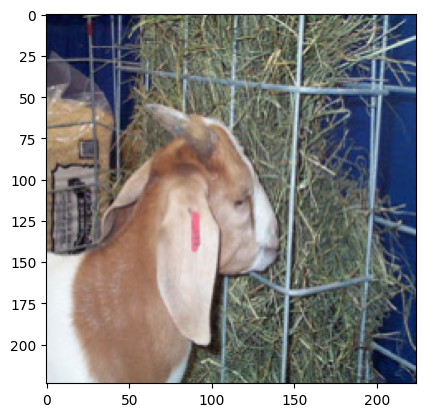

In [7]:
img, label = train_dataset[230]

print(label)

plt.imshow(img.permute(1, 2, 0))

plt.show()

In [8]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
valid_loader = DataLoader(valid_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [9]:
print(len(valid_loader))

144


In [10]:
from CNN_scratch import convNeuralNet

model = convNeuralNet(num_classes=258)

criterion = nn.CrossEntropyLoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate,weight_decay =0.005, momentum=0.9)

In [11]:
def testing_loss(model,dataloader,device):
    total_loss=0
    with torch.no_grad():
        model.eval()
        for batch_idx,(image,label) in enumerate(dataloader):
            
            image = image.to(device)
            label = label.to(device)
            
            pred_label = model(image)
            loss = criterion(pred_label,label)
            total_loss += loss.item()
    return total_loss/len(dataloader)    

In [12]:
num_epochs = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model  = model.to(device)

for epoch in range(num_epochs):
    model.train()
    for batch_idx,(image,label) in enumerate(train_loader):
        image = image.to(device)
        label = label.to(device)
        
        pred_label = model(image)
        loss = criterion(pred_label,label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        if batch_idx%500==0:
            validation_loss = testing_loss(model,valid_loader,device)   
            model.train()
            print(f"EPOCHS [{epoch+1}/{num_epochs}] : LOSS {loss.item():.4f} : VALIDATION LOSS {validation_loss:.4f}")   

cuda
EPOCHS [1/10] : LOSS 5.5694 : VALIDATION LOSS 5.5532
EPOCHS [1/10] : LOSS 5.4567 : VALIDATION LOSS 5.4863
EPOCHS [2/10] : LOSS 5.4978 : VALIDATION LOSS 5.4697
EPOCHS [2/10] : LOSS 5.2955 : VALIDATION LOSS 5.3886
EPOCHS [3/10] : LOSS 5.4455 : VALIDATION LOSS 5.4121
EPOCHS [3/10] : LOSS 5.2796 : VALIDATION LOSS 5.2519
EPOCHS [4/10] : LOSS 4.9806 : VALIDATION LOSS 5.2222
EPOCHS [4/10] : LOSS 5.1582 : VALIDATION LOSS 5.1702
EPOCHS [5/10] : LOSS 5.5101 : VALIDATION LOSS 5.1452
EPOCHS [5/10] : LOSS 5.2758 : VALIDATION LOSS 5.4611
EPOCHS [6/10] : LOSS 5.4971 : VALIDATION LOSS 5.0076
EPOCHS [6/10] : LOSS 5.0728 : VALIDATION LOSS 5.1951
EPOCHS [7/10] : LOSS 4.8783 : VALIDATION LOSS 4.9073
EPOCHS [7/10] : LOSS 4.6294 : VALIDATION LOSS 4.9189
EPOCHS [8/10] : LOSS 4.9229 : VALIDATION LOSS 4.8470
EPOCHS [8/10] : LOSS 5.1231 : VALIDATION LOSS 4.8288
EPOCHS [9/10] : LOSS 5.1388 : VALIDATION LOSS 4.8003
EPOCHS [9/10] : LOSS 4.5120 : VALIDATION LOSS 4.7620
EPOCHS [10/10] : LOSS 4.8917 : VALIDATION

In [13]:

def test_model(model,dataset,device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    with torch.no_grad():
        for batch_idx,(test_image, test_label) in enumerate(dataset):

            image = test_image.to(device)
            label = test_label.to(device)

            pred_label = model(image)
            
            loss = criterion(pred_label,label)
            total_loss += loss.item()
            _, predicted = torch.max(pred_label, dim=1)
            
            total += label.size(0)
            correct += (predicted == label).sum().item()

    return correct/total, total_loss/len(dataset)      


In [14]:
training_accuracy, training_loss = test_model(model,train_loader,device)
validation_accuracy, validation_loss = test_model(model,valid_loader,device)
testing_accuracy, testing_loss = test_model(model,test_loader,device)

print(f"Training Accuracy: {training_accuracy*100:.2f}%")
print(f"Validation Accuracy: {validation_accuracy*100:.2f}%")
print(f"Testing Accuracy: {testing_accuracy*100:.2f}%")

Training Accuracy: 9.86%
Validation Accuracy: 9.74%
Testing Accuracy: 9.73%


In [15]:
print(f"Training Loss: {training_loss:.4f}")
print(f"Validation Loss: {validation_loss:.4f}")
print(f"Testing Loss: {testing_loss:.4f}")

Training Loss: 4.7201
Validation Loss: 4.7692
Testing Loss: 4.7903


In [16]:
def plot_gradcam(model, image_tensor, raw_dataset, target_layer, device):
    grad_cam = GradCam(model, target_layer)
    
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    heatmap, pred_class = grad_cam.generate_heatmap(input_tensor)
    
    orig_img = image_tensor.permute(1, 2, 0).cpu().numpy()
    
    heatmap_resized = cv2.resize(heatmap, (224,224))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)/255.0
    
    overlay = 0.6 * orig_img + 0.4 * heatmap_colored
    overlay = np.clip(overlay, 0, 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(orig_img)
    axes[0].set_title("Original Image")
    
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title(f"Grad-CAM Heatmap")
    
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay")
    
    for ax in axes:
        ax.axis('off')
    plt.show()

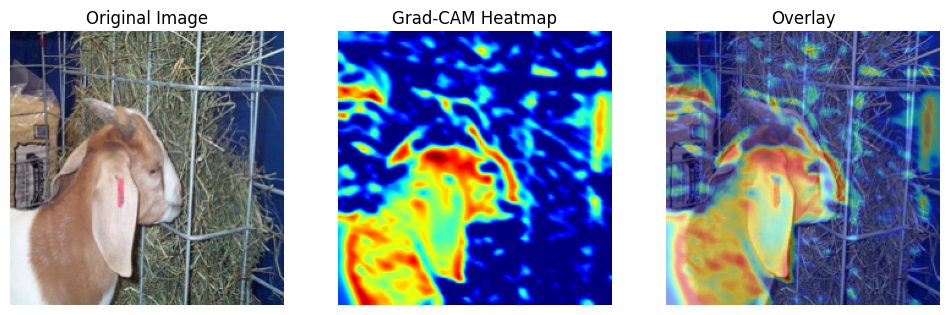

In [17]:

sample_img, sample_label = train_dataset[230]
plot_gradcam(model=model, image_tensor=sample_img, raw_dataset=train_dataset, target_layer=model.conv4, device=device)